In [4]:
import csv
import gzip
import os
import scipy.io
import numpy as np 
import anndata
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import scanpy
import seaborn as sns


In [10]:
# --- INIT ---


# experiment folder
experiment_folder = "/Users/mingyaolab/Dropbox/aorta_circadian_data/datasets/Cumulative-FGC2345_results"

# filtered
use_filtered = True

# get input folder

# input folder
if use_filtered:
    input_folder = '%s/filtered_count_matrices' % experiment_folder
else:
    input_folder = '%s/raw_count_matrices' % experiment_folder

# adata out
adata_path = "%s/adata.h5ad" % (input_folder)

# max mito frac
max_mito_frac = 0.2

# min umi
min_umi = 1000

# fileout
fileout = "%s/adata_qc.h5ad" % input_folder





In [11]:
# --- LOAD ---

adata = anndata.read_h5ad(adata_path)

adata



AnnData object with n_obs × n_vars = 152473 × 32285
    obs: 'batch', 'sample_id', 'lib_size', 'sex', 'misaligned', 'zt', 'percent_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'bmal1_ko'
    var: 'ensembl_id', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [41]:
# --- GET UNIQUE SAMPLE IDS ---

unique_sample_ids = sorted(list(adata.obs['sample_id'].unique()))


In [42]:
# # --- VIZ QC STATS PRIOR TO FILTERING ---

# for sample_id in unique_sample_ids:
    
#     # get the sample adata
#     sample_adata = adata[adata.obs['sample_id'] == sample_id]
    
#     # sample name
#     sample_name = '%s ZT%s %s KO %s' % (sample_adata.obs['sex'].unique()[0], sample_adata.obs['zt'].unique()[0], 'misaligned' if sample_adata.obs['misaligned'].unique()[0] else 'control', sample_adata.obs['bmal1_ko'].unique()[0])


#     print("---- QC PLOTS FOR SAMPLE: %s ---" % sample_name)

# #     sns.jointplot("lib_size", "n_genes_by_counts", data=sample_adata.obs, kind="hex")
# #     sns.jointplot("percent_mito", "n_genes_by_counts", data=sample_adata.obs, kind="hex")
# #     scanpy.pl.highest_expr_genes(sample_adata, n_top=20)
# #     scanpy.pl.violin(sample_adata, ['n_genes_by_counts', 'lib_size', 'percent_mito'],
# #                  jitter=0.4, multi_panel=True)
    
    
    
#     sns.jointplot("lib_size", "n_genes_by_counts", data=sample_adata.obs, kind="hex")
#     sns.jointplot("percent_mito", "n_genes_by_counts", data=sample_adata.obs, kind="hex")
#     scanpy.pl.highest_expr_genes(sample_adata, n_top=20)
#     scanpy.pl.violin(sample_adata, ['n_genes_by_counts', 'lib_size', 'percent_mito'],
#                  jitter=0.4, multi_panel=True)




In [43]:
# --- ADD PASS MITO QC COL ---

# init
mito_qc_pass = np.zeros((adata.shape[0]), dtype = bool)

# fill
mito_qc_pass[np.where(adata.obs['percent_mito'] <= max_mito_frac)[0]] = True
adata.obs['mito_qc_pass'] = mito_qc_pass

# add qc criteria for the mito frac
adata.uns['max_mito_frac'] = max_mito_frac



In [44]:
# --- ADD PASS MIN UMI COL ---

# init
min_umi_qc_pass = np.zeros((adata.shape[0]), dtype = bool)

# fill
min_umi_qc_pass[np.where(adata.obs['lib_size'] >= min_umi)[0]] = True
adata.obs['umi_qc_pass'] = min_umi_qc_pass

# add qc criteria for the mito frac
adata.uns['min_umi'] = min_umi



----- SAMPLE: 99986 ----


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)
/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.63
Detected doublet rate = 0.3%
Estimated detectable doublet fraction = 6.9%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 3.9%
Elapsed time: 3.7 seconds


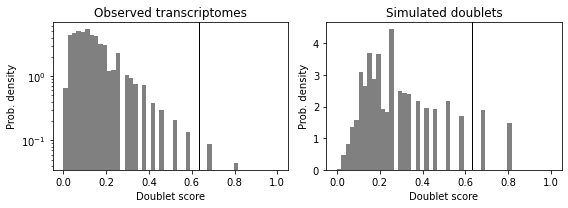

----- SAMPLE: 99987 ----


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.54
Detected doublet rate = 0.5%
Estimated detectable doublet fraction = 12.1%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 4.5%
Elapsed time: 1.4 seconds


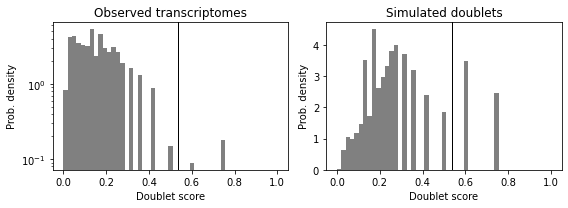

----- SAMPLE: 99988 ----


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.57
Detected doublet rate = 0.5%
Estimated detectable doublet fraction = 12.0%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 3.9%
Elapsed time: 6.1 seconds


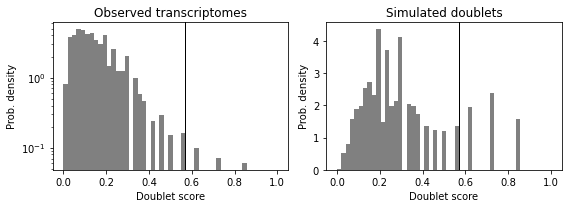

----- SAMPLE: 99989 ----


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.69
Detected doublet rate = 0.2%
Estimated detectable doublet fraction = 4.3%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 4.6%
Elapsed time: 7.0 seconds


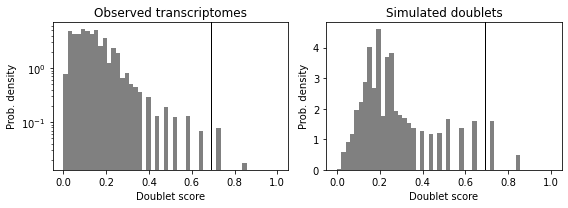

----- SAMPLE: 99990 ----


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.60
Detected doublet rate = 0.4%
Estimated detectable doublet fraction = 9.4%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 3.8%
Elapsed time: 5.8 seconds


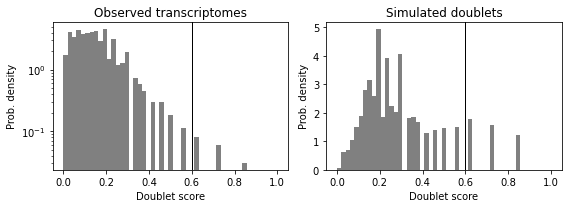

----- SAMPLE: 99991 ----


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.49
Detected doublet rate = 1.0%
Estimated detectable doublet fraction = 15.2%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 6.6%
Elapsed time: 7.0 seconds


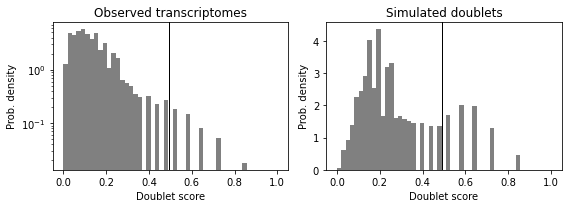

----- SAMPLE: 99992 ----


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.69
Detected doublet rate = 0.2%
Estimated detectable doublet fraction = 4.1%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 5.0%
Elapsed time: 6.5 seconds


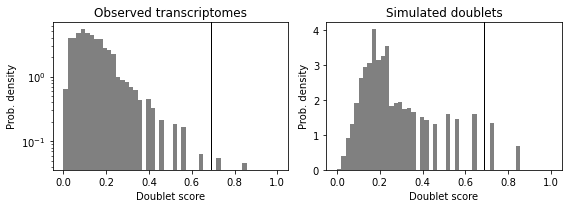

----- SAMPLE: 99993 ----


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.73
Detected doublet rate = 0.1%
Estimated detectable doublet fraction = 2.3%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 2.9%
Elapsed time: 10.1 seconds


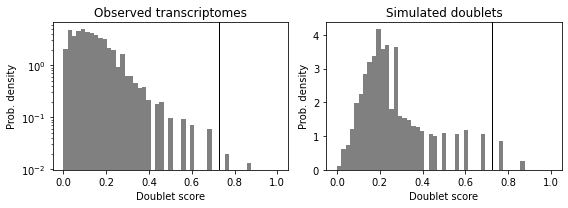

----- SAMPLE: 99994 ----


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.47
Detected doublet rate = 2.6%
Estimated detectable doublet fraction = 26.3%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 9.8%
Elapsed time: 4.3 seconds


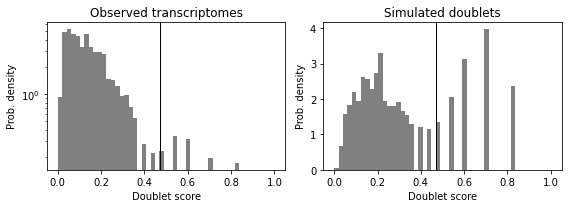

----- SAMPLE: 99995 ----


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.63
Detected doublet rate = 0.4%
Estimated detectable doublet fraction = 8.6%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 4.4%
Elapsed time: 3.5 seconds


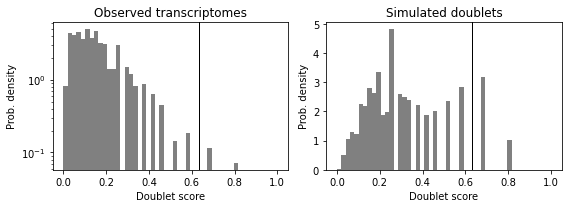

----- SAMPLE: 99996 ----


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.68
Detected doublet rate = 0.2%
Estimated detectable doublet fraction = 7.0%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 3.4%
Elapsed time: 6.1 seconds


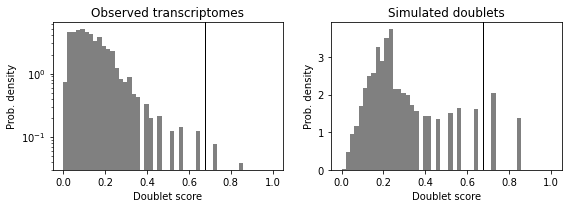

----- SAMPLE: 99997 ----


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.60
Detected doublet rate = 0.5%
Estimated detectable doublet fraction = 10.2%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 5.2%
Elapsed time: 6.5 seconds


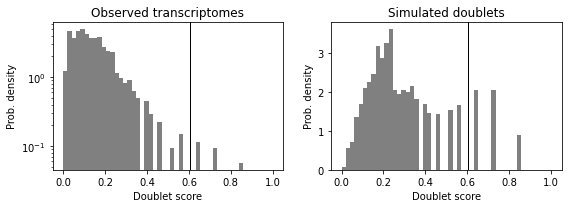

----- SAMPLE: 99998 ----


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.62
Detected doublet rate = 0.4%
Estimated detectable doublet fraction = 10.2%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 4.1%
Elapsed time: 3.4 seconds


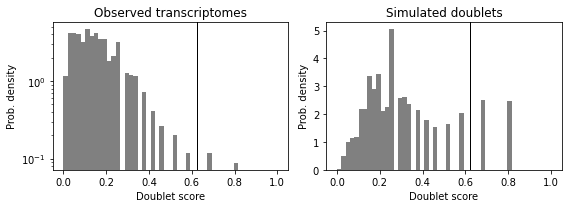

----- SAMPLE: 99999 ----


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.66
Detected doublet rate = 0.3%
Estimated detectable doublet fraction = 6.7%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 4.1%
Elapsed time: 4.9 seconds


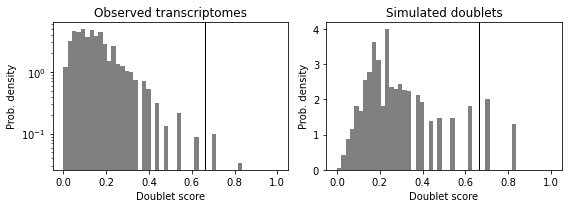

----- SAMPLE: 100000 ----


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.55
Detected doublet rate = 0.6%
Estimated detectable doublet fraction = 12.1%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 4.6%
Elapsed time: 6.8 seconds


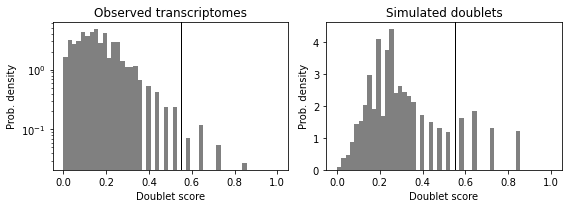

----- SAMPLE: 100001 ----


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.70
Detected doublet rate = 0.2%
Estimated detectable doublet fraction = 3.7%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 4.2%
Elapsed time: 6.0 seconds


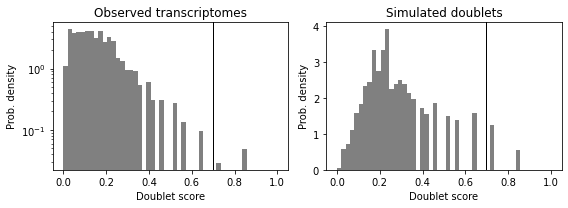

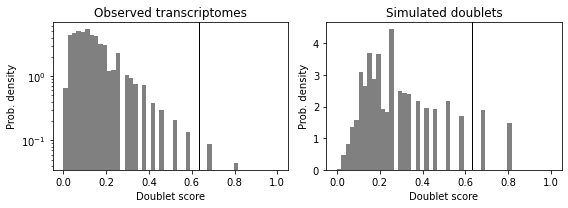

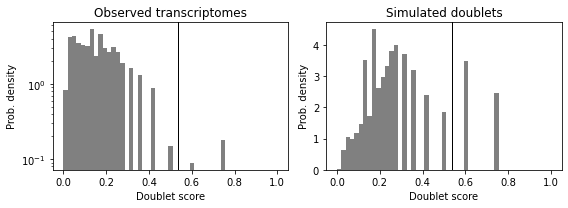

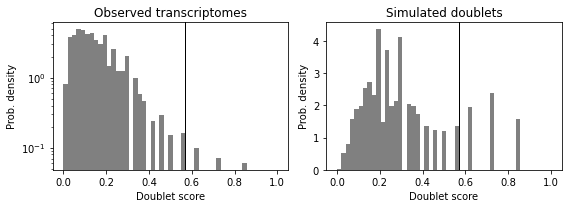

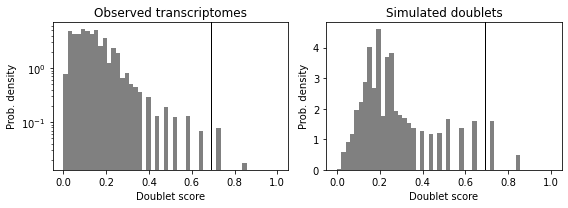

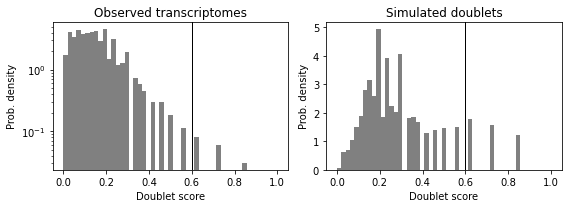

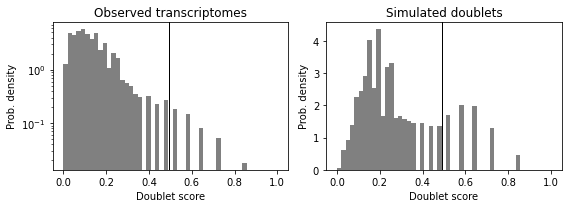

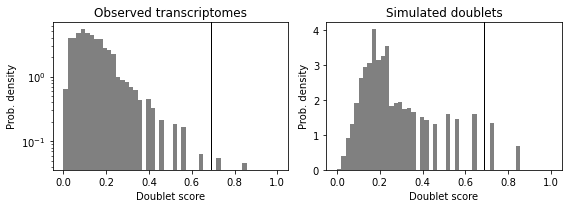

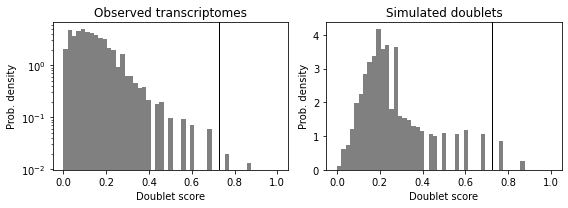

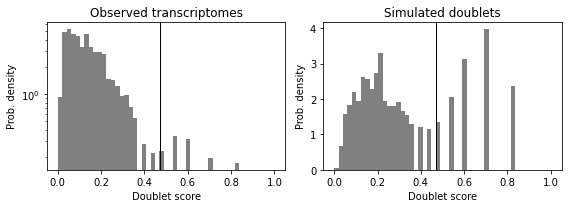

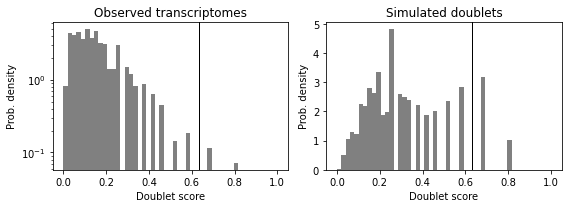

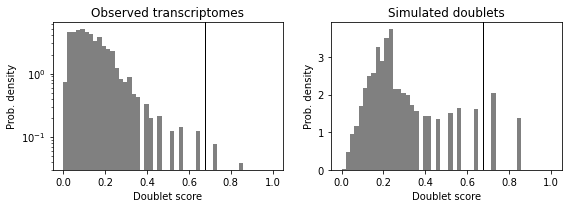

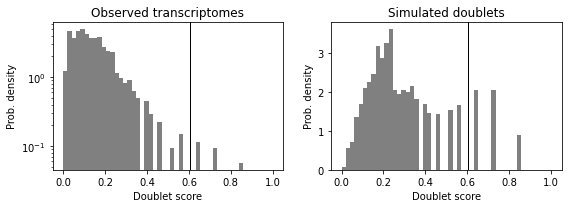

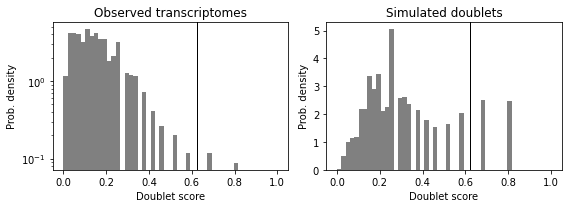

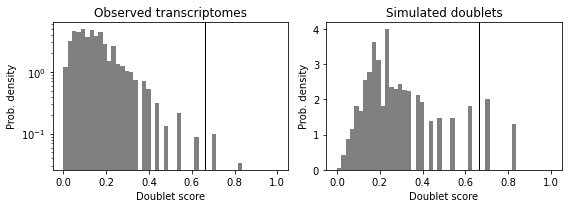

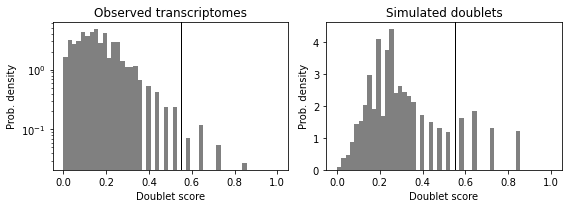

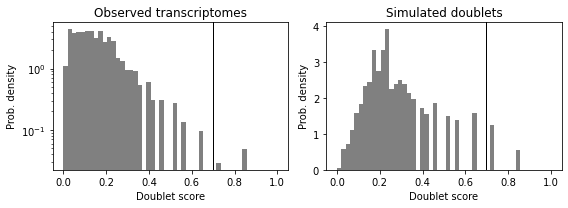

In [45]:
# --- PREDICT DOUBLETS ---


import scrublet as scr

print("Warning: running doublet detection -- assumes cell barcodes are unique.")

# limit adata to those that passed mito % and min UMI
temp_pass_adata = adata[adata.obs['umi_qc_pass'] & adata.obs['mito_qc_pass']]

# init dicts to store the results; keys: cell ID's
doublet_score_dict, doublet_pred_dict = {}, {}

# run Scrublet on each sample separately
for sample_id in unique_sample_ids:
    
    print("----- SAMPLE: %s ----" % sample_id)
    
    
    # limit to the sample
    temp_sample_adata = temp_pass_adata[temp_pass_adata.obs['sample_id'] == sample_id]
    
    # get the sample count matrix
    temp_sample_X = np.array(temp_sample_adata.X.todense())
    
    # run scrublet
    scrub = scr.Scrublet(counts_matrix = temp_sample_X, sim_doublet_ratio = 3)
    doublet_scores, predicted_doublets = scrub.scrub_doublets()
    
    # show
    fig, fig_info = scrub.plot_histogram()
    display(fig)
    
    # make sample doublet dicts
    sample_cell_ids = np.array(temp_sample_adata.obs.index)
    sample_doublet_score_dict = dict(zip(sample_cell_ids, doublet_scores))
    sample_doublet_pred_dict = dict(zip(sample_cell_ids, predicted_doublets))

    # update global dicts
    doublet_score_dict.update(sample_doublet_score_dict)
    doublet_pred_dict.update(sample_doublet_pred_dict)

    
    



In [46]:
# --- ADD THE DOUBLET QC INFO ---

# init
adata.obs['doublet_qc_pass'] = False
adata.obs['doublet_score'] = False

# add doublet score
keys = list(doublet_score_dict.keys())
vals = list(doublet_score_dict.values())
adata.obs.loc[keys, 'doublet_score'] = np.array(vals)

# add doublet pass
keys = list(doublet_pred_dict.keys())
vals = list(doublet_pred_dict.values())
adata.obs.loc[keys, 'doublet_qc_pass'] = ~np.array(vals)


adata.obs


,sample_id,within_experiment_batch_id,lib_size,sex,misaligned,zt,bmal1_ko,batch,percent_mito,n_genes_by_counts,...,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,mito_qc_pass,umi_qc_pass,doublet_qc_pass,doublet_score
index,,,,,,,,,,,,,,,,,,,,,
AAACCCAAGTAACCGG-1,99998,0,17552.0,male,True,0,False,1,0.121069,4194,...,17552.0,9.772980,33.443482,41.721741,51.891522,64.870100,True,True,True,0.264851
AAACCCAAGTGTTGTC-1,99998,0,14079.0,male,True,0,False,1,0.067263,3517,...,14079.0,9.552510,32.424178,41.778535,52.532140,66.553022,True,True,True,0.285714
AAACCCACAACGGGTA-1,99998,0,17550.0,male,True,0,False,1,0.067407,4366,...,17550.0,9.772866,28.039886,36.678063,47.048433,60.894587,True,True,True,0.370000
AAACGAAAGATGCTTC-1,99998,0,11416.0,male,True,0,False,1,0.095743,3410,...,11416.0,9.342858,30.921514,39.374562,49.360547,63.270848,True,True,True,0.370000
AAACGAAAGCCGATAG-1,99998,0,29874.0,male,True,0,False,1,0.055935,5366,...,29874.0,10.304777,29.296378,38.207137,48.751423,62.907545,True,True,True,0.115869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTATGAGAT-1,99986,15,950.0,female,False,0,False,1,0.418947,337,...,950.0,6.857514,68.421053,75.052632,85.578947,100.000000,False,False,False,False
TTTGTTGTCAATCCAG-1,99986,15,1377.0,female,False,0,False,1,0.742919,192,...,1377.0,7.228388,89.687727,93.318809,100.000000,100.000000,False,True,False,False
TTTGTTGTCACTCGAA-1,99986,15,734.0,female,False,0,False,1,0.854223,75,...,734.0,6.599871,96.594005,100.000000,100.000000,100.000000,False,False,False,False


In [47]:
# # --- ADD QC PASS COL ---


# limit adata to those that passed 
adata.obs['qc_pass'] = (adata.obs['umi_qc_pass']) & (adata.obs['mito_qc_pass']) & (adata.obs['doublet_qc_pass'])

print("%s of %s cells pass QC" % (adata[adata.obs['qc_pass']].shape[0], adata.shape[0]))




74243 of 96998 cells pass QC


/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)


In [48]:
# --- WRITE OUT ---

adata.write(fileout)



... storing 'doublet_score' as categorical


In [49]:
# --- HOW MANY FROM EACH SAMPLE PASS? ---

# unique sample ids
unique_sample_ids = sorted(list(adata.obs['sample_id'].unique()))

# lists to store
sample_name_list = []
num_cells_list = []
num_qc_pass_list = []
num_mito_pass_list = []
num_umi_pass_list = []
num_doublet_pass_list = []
med_umi_list = []
med_genes_list = []
for sample_id in unique_sample_ids:

    # get sample adata
    sample_adata = adata[adata.obs['sample_id'] == sample_id]
    passing_sample_adata = sample_adata[sample_adata.obs['qc_pass']]
    
    # make the sample name
    sample_name = '%s ZT%s %s' % (sample_adata.obs['sex'].unique()[0], sample_adata.obs['zt'].unique()[0], 'misaligned' if sample_adata.obs['misaligned'].unique()[0] else 'control')
    
    # get the mito and umi passing indices
    mito_passing_indices = np.where(sample_adata.obs['mito_qc_pass'])[0]
    umi_passing_indices = np.where(sample_adata.obs['umi_qc_pass'])[0]
    doublet_passing_indices = np.where(sample_adata.obs['doublet_qc_pass'])[0]
    
    # get the intersecting
    intersect_passing_indices = np.intersect1d(mito_passing_indices, umi_passing_indices)
    
    # num passing 
    num_passing = intersect_passing_indices.size
    num_mito_passing = mito_passing_indices.size
    num_doublet_passing = doublet_passing_indices.size
    num_umi_passing = umi_passing_indices.size
    
    # median UMI
    median_umi = np.median(passing_sample_adata.obs['lib_size'])
    
    # median genes detected
    median_genes_detected = np.median(sample_adata.obs['n_genes_by_counts'])
    
    
    # add
    sample_name_list.append(sample_name)
    num_cells_list.append(sample_adata.shape[0])
    num_qc_pass_list.append(num_passing)
    num_mito_pass_list.append(num_mito_passing)
    num_umi_pass_list.append(num_umi_passing)
    num_doublet_pass_list.append(num_doublet_passing)
    med_umi_list.append(median_umi)
    med_genes_list.append(median_genes_detected)
    
    
    # print("Sample name: %s; Num cells: %s; Num qc pass: %s, Num mito pass: %s; Num umi pass: %s" % (sample_name, sample_adata.shape[0], num_passing, num_mito_passing, num_umi_passing))

    
# make df
qc_df = pd.DataFrame()
qc_df['Sample name'] = sample_name_list
qc_df['Num cells'] = num_cells_list
qc_df['QC pass'] = num_qc_pass_list
qc_df['Frac QC pass'] = qc_df['QC pass'] / qc_df['Num cells']
qc_df['Mito QC pass'] = num_mito_pass_list
qc_df['UMI QC pass'] = num_umi_pass_list
qc_df['Doublet QC pass'] = num_doublet_pass_list
qc_df['Median UMI (passed)'] = med_umi_list
qc_df['Median genes detected (passed)'] = med_genes_list


# show
display(qc_df)



/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)
/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)
/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will be removed in a future version.
  res = method(*args, **kwargs)
/anaconda2/envs/scrublet/lib/python3.8/site-packages/pandas/core/arrays/categorical.py:2487: FutureWarning: The `inplace` parameter in pandas.Categorical.remove_unused_categories is deprecated and will 

,Sample name,Num cells,QC pass,Frac QC pass,Mito QC pass,UMI QC pass,Doublet QC pass,Median UMI (passed),Median genes detected (passed)
0,female ZT0 control,4497,3326,0.739604,3416,4141,3317,11901.0,3111.0
1,female ZT6 control,2643,1660,0.628074,1753,2383,1651,14231.0,2884.0
2,female ZT12 control,6146,4879,0.793850,5122,5669,4856,13139.0,3360.5
3,female ZT18 control,7497,5588,0.745365,5803,6893,5577,12288.0,3110.0
4,male ZT0 control,6009,4828,0.803461,4970,5597,4811,13094.0,3336.0
5,male ZT6 control,6380,5517,0.864734,5702,6029,5462,12830.5,3400.5
6,male ZT12 control,6421,5302,0.825728,5557,5991,5291,12982.0,3350.0
7,male ZT18 control,8960,7487,0.835603,7754,8445,7482,12553.0,3300.0
8,female ZT0 misaligned,7448,3997,0.536654,4660,6139,3894,11966.0,1125.5
9,female ZT6 misaligned,5331,3431,0.643594,3554,4775,3418,13676.5,3122.0


In [50]:
# # --- VIZ QC AFTER MITO FILTERING ---

# for sample_id in sorted(list(adata.obs['sample_id'].unique())):
    
#     # get the sample adata
#     sample_adata = adata[adata.obs['sample_id'] == sample_id]
#     sample_adata = sample_adata[sample_adata.obs['mito_qc_pass']]
    
#     # sample name
#     sample_name = '%s ZT%s %s' % (sample_adata.obs['sex'].unique()[0], sample_adata.obs['zt'].unique()[0], 'misaligned' if sample_adata.obs['misaligned'].unique()[0] else 'control')


#     print("---- QC PLOTS FOR SAMPLE: %s ---" % sample_name)

#     sns.jointplot("lib_size", "n_genes_by_counts", data=sample_adata.obs, kind="hex")
#     sns.jointplot("percent_mito", "n_genes_by_counts", data=sample_adata.obs, kind="hex")
#     scanpy.pl.highest_expr_genes(sample_adata, n_top=20)
#     scanpy.pl.violin(sample_adata, ['n_genes_by_counts', 'lib_size', 'percent_mito'],
#                  jitter=0.4, multi_panel=True)
    
    


In [51]:
# # --- VIZ CELLS AFTER BOTH MITO AND UMI QC FILTER ---


# for sample_id in sorted(list(adata.obs['sample_id'].unique())):
    
#     # get the sample adata
#     sample_adata = adata[adata.obs['sample_id'] == sample_id]
#     sample_adata = sample_adata[(sample_adata.obs['mito_qc_pass']) & (sample_adata.obs['umi_qc_pass'])]
    
#     # sample name
#     sample_name = '%s ZT%s %s' % (sample_adata.obs['sex'].unique()[0], sample_adata.obs['zt'].unique()[0], 'misaligned' if sample_adata.obs['misaligned'].unique()[0] else 'control')

    
#     print("---- QC PLOTS FOR SAMPLE: %s ---" % sample_name)

#     sns.jointplot("lib_size", "n_genes_by_counts", data=sample_adata.obs, kind="hex")
#     sns.jointplot("percent_mito", "n_genes_by_counts", data=sample_adata.obs, kind="hex")
#     scanpy.pl.highest_expr_genes(sample_adata, n_top=20)
#     scanpy.pl.violin(sample_adata, ['n_genes_by_counts', 'lib_size', 'percent_mito'],
#                  jitter=0.4, multi_panel=True)
    
#     break
    
    


In [ ]:
# --- FILTER CELLS FOR LOW NUMBER OF GENES DETECTED ---


# vals = np.linspace(3,5,100)
# line = (((3.5 - 2.5) / (5.0 - 3.0)) * vals) + 2.5 - 1.5 # 2.5 - 1.5
# below_line = np.log10(num_genes_detected) < (((3.5 - 2.5) / (5.0 - 3.0)) * np.log10(adata.obs['lib_size'])) + 2.5 - 1.5
# adata.obs['below_line'] = below_line



In [52]:
# # --- VIZ CELLS AFTER ALL QC FILTER ---

# for sample_id in sorted(list(adata.obs['sample_id'].unique())):
    
#     # get the sample adata
#     sample_adata = adata[adata.obs['sample_id'] == sample_id]
#     sample_adata = sample_adata[(sample_adata.obs['qc_pass'])]
    
#     # sample name
#     sample_name = '%s ZT%s %s' % (sample_adata.obs['sex'].unique()[0], sample_adata.obs['zt'].unique()[0], 'misaligned' if sample_adata.obs['misaligned'].unique()[0] else 'control')

    
#     print("---- QC PLOTS FOR SAMPLE: %s ---" % sample_name)

#     sns.jointplot("lib_size", "n_genes_by_counts", data=sample_adata.obs, kind="hex")
#     sns.jointplot("percent_mito", "n_genes_by_counts", data=sample_adata.obs, kind="hex")
#     scanpy.pl.highest_expr_genes(sample_adata, n_top=20)
#     scanpy.pl.violin(sample_adata, ['n_genes_by_counts', 'lib_size', 'percent_mito'],
#                  jitter=0.4, multi_panel=True)
    
    
